In [1]:
# Run this first — installs everything needed for the full pipeline
!pip install transformers==4.40.0 datasets torch scikit-learn \
             matplotlib seaborn wordcloud --quiet

print('✅ All packages installed')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 102.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.3.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
✅ All packages installed


In [2]:
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── Device ────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
else:
    print('⚠️  No GPU found — go to Runtime > Change runtime type > T4 GPU')

✅ Device: cuda
   GPU: Tesla T4


In [4]:
train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

print(f'Train: {train_df.shape} | Test: {test_df.shape}')
print(f'\nColumns: {train_df.columns.tolist()}')
print(f'\nMissing values:\n{train_df.isnull().sum()}')

vc = train_df['target'].value_counts()
print(f'\nEmergency    (1): {vc[1]:,} ({vc[1]/len(train_df)*100:.1f}%)')
print(f'Non-Emergency(0): {vc[0]:,} ({vc[0]/len(train_df)*100:.1f}%)')
train_df.head(5)

Train: (7613, 5) | Test: (3263, 4)

Columns: ['id', 'keyword', 'location', 'text', 'target']

Missing values:
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

Emergency    (1): 3,271 (43.0%)
Non-Emergency(0): 4,342 (57.0%)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


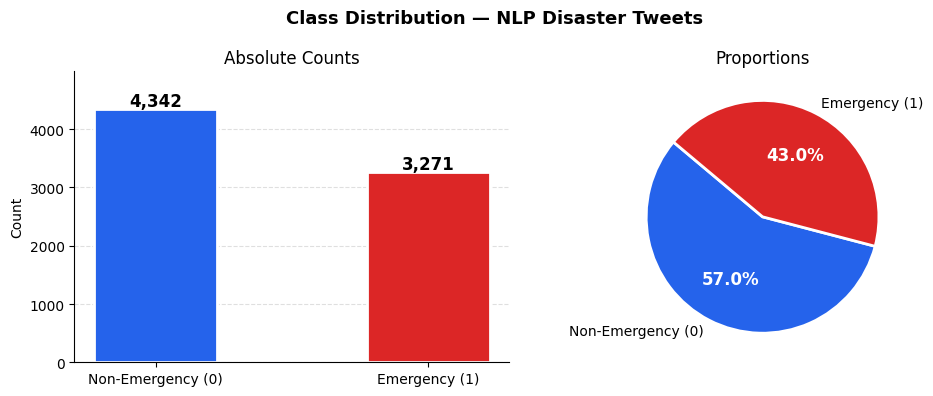

In [5]:
import matplotlib.pyplot as plt

vc = train_df['target'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Class Distribution — NLP Disaster Tweets', fontsize=13, fontweight='bold')

COLORS = ['#2563EB', '#DC2626']
labels = ['Non-Emergency (0)', 'Emergency (1)']
counts = [vc[0], vc[1]]

# Bar chart
bars = axes[0].bar(labels, counts, color=COLORS, width=0.45, edgecolor='white', linewidth=2)
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{cnt:,}', ha='center', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, max(counts) * 1.15)
axes[0].set_ylabel('Count'); axes[0].set_title('Absolute Counts')
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].yaxis.grid(True, linestyle='--', alpha=0.4)
axes[0].set_axisbelow(True)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts, labels=labels, colors=COLORS,
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(linewidth=2, edgecolor='white'),
    textprops={'fontsize': 10}
)
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight('bold'); at.set_color('white')
axes[1].set_title('Proportions')

plt.tight_layout()
plt.show()

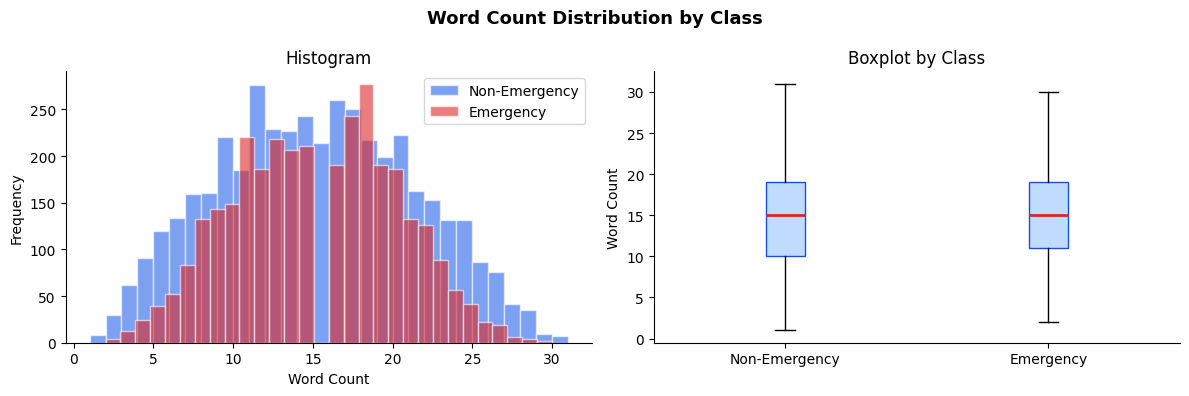

       word_count                                         char_count         \
            count  mean  std  min   25%   50%   75%   max      count   mean   
target                                                                        
0          4342.0  14.7  6.2  1.0  10.0  15.0  19.0  31.0     4342.0   95.7   
1          3271.0  15.2  5.1  2.0  11.0  15.0  19.0  30.0     3271.0  108.1   

                                               
         std   min   25%    50%    75%    max  
target                                         
0       35.9   7.0  68.0  101.0  130.0  157.0  
1       29.3  14.0  88.0  115.0  136.0  151.0  


In [6]:
train_df['word_count'] = train_df['text'].apply(lambda x: len(str(x).split()))
train_df['char_count'] = train_df['text'].apply(lambda x: len(str(x)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Word Count Distribution by Class', fontsize=13, fontweight='bold')

for cls, color, label in [(0, '#2563EB', 'Non-Emergency'), (1, '#DC2626', 'Emergency')]:
    subset = train_df[train_df['target'] == cls]['word_count']
    axes[0].hist(subset, bins=30, alpha=0.6, color=color, label=label, edgecolor='white')

axes[0].set_xlabel('Word Count'); axes[0].set_ylabel('Frequency')
axes[0].set_title('Histogram'); axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].boxplot(
    [train_df[train_df['target'] == 0]['word_count'],
     train_df[train_df['target'] == 1]['word_count']],
    labels=['Non-Emergency', 'Emergency'],
    patch_artist=True,
    boxprops=dict(facecolor='#BFDBFE', color='#1D4ED8'),
    medianprops=dict(color='#DC2626', linewidth=2)
)
axes[1].set_ylabel('Word Count'); axes[1].set_title('Boxplot by Class')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout(); plt.show()

print(train_df.groupby('target')[['word_count', 'char_count']].describe().round(1))

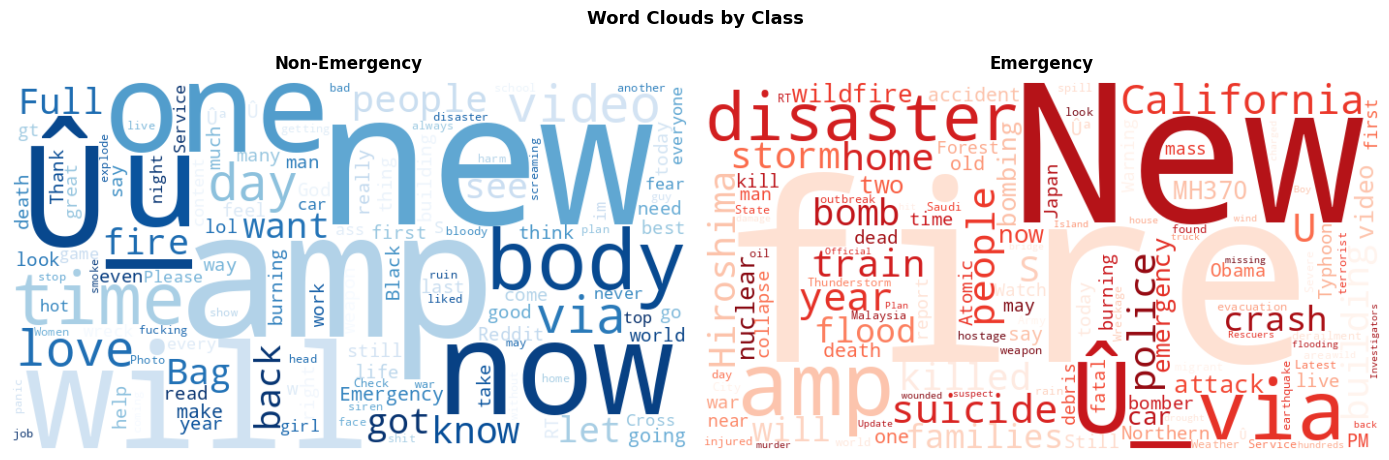

In [7]:
import re
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Word Clouds by Class', fontsize=13, fontweight='bold')

for ax, cls, title, cmap in [
    (axes[0], 0, 'Non-Emergency', 'Blues'),
    (axes[1], 1, 'Emergency',     'Reds'),
]:
    text = ' '.join(train_df[train_df['target'] == cls]['text'].astype(str))
    text = re.sub(r'http\S+|www\S+|@\w+|#', '', text)
    wc = WordCloud(
        width=700, height=380,
        background_color='white',
        colormap=cmap,
        max_words=120,
        collocations=False
    ).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)

plt.tight_layout(); plt.show()

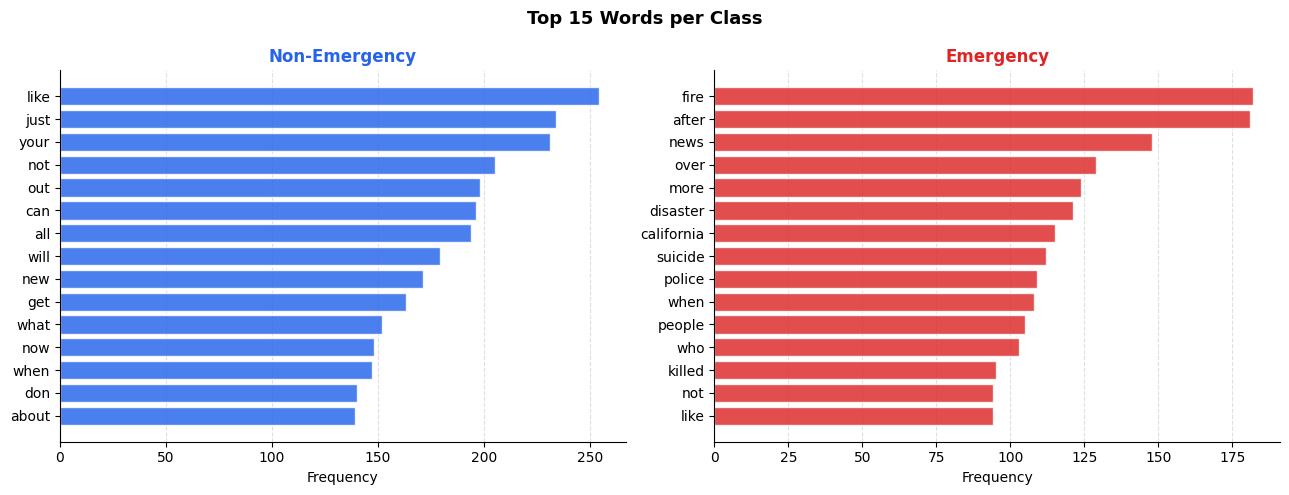

In [8]:
from collections import Counter

STOPWORDS = {
    'the','a','an','and','or','but','in','on','at','to',
    'for','of','with','is','was','are','were','it','this',
    'that','i','my','we','you','he','she','they','be','been',
    'have','has','had','do','does','did','so','if','as',
    'up','by','from','its','our','their','amp','rt','via'
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Top 15 Words per Class', fontsize=13, fontweight='bold')

for ax, cls, title, color in [
    (axes[0], 0, 'Non-Emergency', '#2563EB'),
    (axes[1], 1, 'Emergency',     '#DC2626'),
]:
    text = ' '.join(train_df[train_df['target'] == cls]['text'].astype(str))
    text = re.sub(r'http\S+|www\S+|@\w+|#|[^a-zA-Z\s]', ' ', text).lower()
    words = [w for w in text.split() if w not in STOPWORDS and len(w) > 2]
    top15 = Counter(words).most_common(15)
    w_list, freqs = zip(*top15)

    ax.barh(list(reversed(w_list)), list(reversed(freqs)),
            color=color, alpha=0.82, edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Frequency')
    ax.spines[['top', 'right']].set_visible(False)
    ax.xaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

plt.tight_layout(); plt.show()

In [9]:
import re

def clean_text(text):
    """
    Light cleaning that preserves meaning-bearing tokens.
    Deliberately does NOT remove stop words — BERT handles
    that via attention. Removing 'not', 'no', 'never' from
    emergency sentences would flip their meaning entirely.
    """
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)       # remove URLs
    text = re.sub(r'<.*?>', '', text)                  # remove HTML tags
    text = re.sub(r'@\w+', '', text)                    # remove @mentions
    text = re.sub(r'#(\w+)', r'\1', text)               # keep hashtag word
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)           # remove non-ASCII
    text = re.sub(r'\s+', ' ', text).strip()             # normalise whitespace
    return text


def build_input(row):
    """
    Optionally prepend the keyword to give BERT extra context.
    e.g.  'wildfire : Forest fire near La Ronge Sask. Canada'
    """
    cleaned = clean_text(row['text'])
    if pd.notna(row['keyword']) and str(row['keyword']).strip():
        keyword = str(row['keyword']).replace('%20', ' ').strip()
        return f'{keyword} : {cleaned}'
    return cleaned


# Apply to both splits
train_df['input_text'] = train_df.apply(build_input, axis=1)
test_df['input_text']  = test_df.apply(build_input,  axis=1)

# Sanity check — print a few examples
print('Sample cleaned inputs:\n')
for _, row in train_df[['input_text', 'target']].head(6).iterrows():
    label = '🚨 EMERGENCY' if row['target'] == 1 else '✅ NORMAL'
    print(f'  [{label}]  {row["input_text"][:90]}')

Sample cleaned inputs:

  [🚨 EMERGENCY]  Our Deeds are the Reason of this earthquake May ALLAH Forgive us all
  [🚨 EMERGENCY]  Forest fire near La Ronge Sask. Canada
  [🚨 EMERGENCY]  All residents asked to 'shelter in place' are being notified by officers. No other evacuat
  [🚨 EMERGENCY]  13,000 people receive wildfires evacuation orders in California
  [🚨 EMERGENCY]  Just got sent this photo from Ruby Alaska as smoke from wildfires pours into a school
  [🚨 EMERGENCY]  RockyFire Update => California Hwy. 20 closed in both directions due to Lake County fire -


In [10]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_df['input_text'].tolist(),
    train_df['target'].tolist(),
    test_size=0.10,           # 90% train, 10% val
    random_state=SEED,
    stratify=train_df['target'].tolist()  # keeps class balance in both splits
)

test_texts = test_df['input_text'].tolist()

print(f'Train samples      : {len(train_texts):,}')
print(f'Validation samples : {len(val_texts):,}')
print(f'Test samples       : {len(test_texts):,}')

# Confirm class balance is preserved in val split
val_series = pd.Series(val_labels)
print(f'\nVal class balance:')
print(f'  Emergency (1)    : {val_series.sum()} ({val_series.mean()*100:.1f}%)')
print(f'  Non-Emergency (0): {(~val_series.astype(bool)).sum()} ({(1-val_series.mean())*100:.1f}%)')

Train samples      : 6,851
Validation samples : 762
Test samples       : 3,263

Val class balance:
  Emergency (1)    : 327 (42.9%)
  Non-Emergency (0): 435 (57.1%)


In [11]:
from transformers import BertTokenizer

MODEL_NAME = 'bert-base-uncased'
MAX_LEN    = 128
BATCH_SIZE = 16

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print(f'✅ Tokenizer loaded: {MODEL_NAME}')

# Check that MAX_LEN=128 covers our data comfortably
lengths = [
    len(tokenizer.encode(t, truncation=False))
    for t in train_texts[:500]      # sample 500 for speed
]
print(f'\nToken length stats (sample of 500):')
print(f'  Mean : {sum(lengths)/len(lengths):.1f}')
print(f'  Max  : {max(lengths)}')
print(f'  Min  : {min(lengths)}')
print(f'  Over {MAX_LEN} tokens: {sum(l > MAX_LEN for l in lengths)} / {len(lengths)}')
print(f'\nMAX_LEN={MAX_LEN} covers all sequences safely ✅')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

✅ Tokenizer loaded: bert-base-uncased

Token length stats (sample of 500):
  Mean : 23.9
  Max  : 55
  Min  : 4
  Over 128 tokens: 0 / 500

MAX_LEN=128 covers all sequences safely ✅


In [12]:
from torch.utils.data import Dataset
import torch

class EmergencyDataset(Dataset):
    """
    PyTorch Dataset for BERT sequence classification.

    Args:
        texts     : list of cleaned input strings
        labels    : list of int (0 or 1). Pass None for test set.
        tokenizer : HuggingFace BertTokenizer instance
        max_len   : maximum token sequence length (default 128)

    Returns per item:
        input_ids      — token indices          [max_len]
        attention_mask — 1=real token, 0=pad    [max_len]
        token_type_ids — all 0s (single sent.)  [max_len]
        labels         — int tensor (train/val only)
    """

    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        item = {
            'input_ids'      : encoding['input_ids'].squeeze(),
            'attention_mask' : encoding['attention_mask'].squeeze(),
            'token_type_ids' : encoding['token_type_ids'].squeeze(),
        }
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


print('✅ EmergencyDataset class defined')

✅ EmergencyDataset class defined


In [13]:
from torch.utils.data import DataLoader

# ── Build datasets ────────────────────────────────────────────
train_dataset = EmergencyDataset(train_texts, train_labels, tokenizer, MAX_LEN)
val_dataset   = EmergencyDataset(val_texts,   val_labels,   tokenizer, MAX_LEN)
test_dataset  = EmergencyDataset(test_texts,  None,         tokenizer, MAX_LEN)

# ── Build dataloaders ─────────────────────────────────────────
# num_workers=2 speeds up data loading on Colab's CPU cores
# pin_memory=True speeds up CPU→GPU tensor transfer
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train batches : 429
Val batches   : 48
Test batches  : 204


In [14]:
# Pull one batch and confirm shapes — catches tokenizer issues early
sample_batch = next(iter(train_loader))

print('Batch keys     :', list(sample_batch.keys()))
print(f'input_ids      : {sample_batch["input_ids"].shape}')
print(f'attention_mask : {sample_batch["attention_mask"].shape}')
print(f'token_type_ids : {sample_batch["token_type_ids"].shape}')
print(f'labels         : {sample_batch["labels"].shape}')
print(f'label values   : {sample_batch["labels"].tolist()}')

# Decode first sequence back to text to confirm tokenisation looks right
decoded = tokenizer.decode(
    sample_batch['input_ids'][0],
    skip_special_tokens=True
)
print(f'\nDecoded sample :\n  "{decoded[:120]}"')
print('\n✅ DataLoaders look good — ready for training')

Batch keys     : ['input_ids', 'attention_mask', 'token_type_ids', 'labels']
input_ids      : torch.Size([16, 128])
attention_mask : torch.Size([16, 128])
token_type_ids : torch.Size([16, 128])
labels         : torch.Size([16])
label values   : [0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0]

Decoded sample :
  "demolish : nothing you midget i will demolish you show some respect"

✅ DataLoaders look good — ready for training


In [15]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    output_attentions=False,
    output_hidden_states=False
)
model = model.to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ BERT loaded on {DEVICE}')
print(f'   Total params    : {total/1e6:.1f}M')
print(f'   Trainable params: {trainable/1e6:.1f}M')

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ BERT loaded on cuda
   Total params    : 109.5M
   Trainable params: 109.5M


In [16]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

EPOCHS       = 4
LR           = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.10

total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

optimizer = AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f'Total training steps : {total_steps}')
print(f'Warmup steps         : {warmup_steps}')
print(f'Epochs               : {EPOCHS}')
print(f'Learning rate        : {LR}')
print('✅ Optimizer and scheduler ready')

Total training steps : 1716
Warmup steps         : 171
Epochs               : 4
Learning rate        : 2e-05
✅ Optimizer and scheduler ready


In [17]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []

    for step, batch in enumerate(loader):
        optimizer.zero_grad()

        outputs = model(
            input_ids=batch['input_ids'].to(device),
            attention_mask=batch['attention_mask'].to(device),
            token_type_ids=batch['token_type_ids'].to(device),
            labels=batch['labels'].to(device)
        )

        outputs.loss.backward()

        # Clip gradients — prevents exploding gradients with BERT
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += outputs.loss.item()
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(batch['labels'].numpy())

        if (step + 1) % 100 == 0:
            print(f'    step {step+1}/{len(loader)}  loss={outputs.loss.item():.4f}')

    return (
        total_loss / len(loader),
        accuracy_score(all_labels, all_preds),
        f1_score(all_labels, all_preds, average='binary')
    )


def eval_epoch(model, loader, device):
    model.eval()
    total_loss, all_preds, all_labels, all_probs = 0, [], [], []

    with torch.no_grad():
        for batch in loader:
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device),
                token_type_ids=batch['token_type_ids'].to(device),
                labels=batch['labels'].to(device)
            )
            total_loss += outputs.loss.item()

            probs = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()

            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(batch['labels'].numpy())

    return {
        'loss'      : total_loss / len(loader),
        'accuracy'  : accuracy_score(all_labels, all_preds),
        'precision' : precision_score(all_labels, all_preds, average='binary'),
        'recall'    : recall_score(all_labels, all_preds,    average='binary'),
        'f1'        : f1_score(all_labels, all_preds,         average='binary'),
        'preds'     : all_preds,
        'labels'    : all_labels,
        'probs'     : all_probs,
    }

print('✅ train_epoch and eval_epoch functions defined')

✅ train_epoch and eval_epoch functions defined


In [18]:
import time

history = {
    'train_loss': [], 'val_loss': [],
    'train_f1':  [], 'val_f1':  [],
    'val_acc':   [], 'val_precision': [], 'val_recall': []
}
best_val_f1  = 0.0
best_epoch   = 0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    print(f'\n{"="*55}')
    print(f'  EPOCH {epoch} / {EPOCHS}')
    print(f'{"="*55}')

    # ── Train ─────────────────────────────────────────────────
    t_loss, t_acc, t_f1 = train_epoch(
        model, train_loader, optimizer, scheduler, DEVICE
    )

    # ── Validate ──────────────────────────────────────────────
    v = eval_epoch(model, val_loader, DEVICE)

    elapsed = time.time() - t0
    print(f'\n  Train  — loss: {t_loss:.4f} | f1: {t_f1:.4f}')
    print(f'  Val    — loss: {v["loss"]:.4f} | acc: {v["accuracy"]:.4f} | '
          f'prec: {v["precision"]:.4f} | rec: {v["recall"]:.4f} | f1: {v["f1"]:.4f}')
    print(f'  Time   — {elapsed/60:.1f} min')

    # ── Track history ─────────────────────────────────────────
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v['loss'])
    history['train_f1'].append(t_f1)
    history['val_f1'].append(v['f1'])
    history['val_acc'].append(v['accuracy'])
    history['val_precision'].append(v['precision'])
    history['val_recall'].append(v['recall'])

    # ── Save best checkpoint ──────────────────────────────────
    if v['f1'] > best_val_f1:
        best_val_f1 = v['f1']
        best_epoch  = epoch
        torch.save(model.state_dict(), 'best_bert_emergency.pt')
        print(f'  ✅ Best model saved  (epoch {epoch}, val F1={best_val_f1:.4f})')

print(f'\n🏆 Training complete!')
print(f'   Best epoch : {best_epoch}')
print(f'   Best val F1: {best_val_f1:.4f}')


  EPOCH 1 / 4
    step 100/429  loss=0.5592
    step 200/429  loss=0.3622
    step 300/429  loss=0.3110
    step 400/429  loss=0.3962

  Train  — loss: 0.4773 | f1: 0.7237
  Val    — loss: 0.3754 | acc: 0.8478 | prec: 0.8754 | rec: 0.7523 | f1: 0.8092
  Time   — 2.8 min
  ✅ Best model saved  (epoch 1, val F1=0.8092)

  EPOCH 2 / 4
    step 100/429  loss=0.3095
    step 200/429  loss=0.1310
    step 300/429  loss=0.2402
    step 400/429  loss=0.4810

  Train  — loss: 0.3351 | f1: 0.8414
  Val    — loss: 0.4553 | acc: 0.8150 | prec: 0.7598 | rec: 0.8318 | f1: 0.7942
  Time   — 2.9 min

  EPOCH 3 / 4
    step 100/429  loss=0.5115
    step 200/429  loss=0.6244
    step 300/429  loss=0.0802
    step 400/429  loss=0.0436

  Train  — loss: 0.2482 | f1: 0.8963
  Val    — loss: 0.4583 | acc: 0.8294 | prec: 0.7839 | rec: 0.8318 | f1: 0.8071
  Time   — 2.9 min

  EPOCH 4 / 4
    step 100/429  loss=0.1549
    step 200/429  loss=0.3029
    step 300/429  loss=0.3460
    step 400/429  loss=0.0176

 

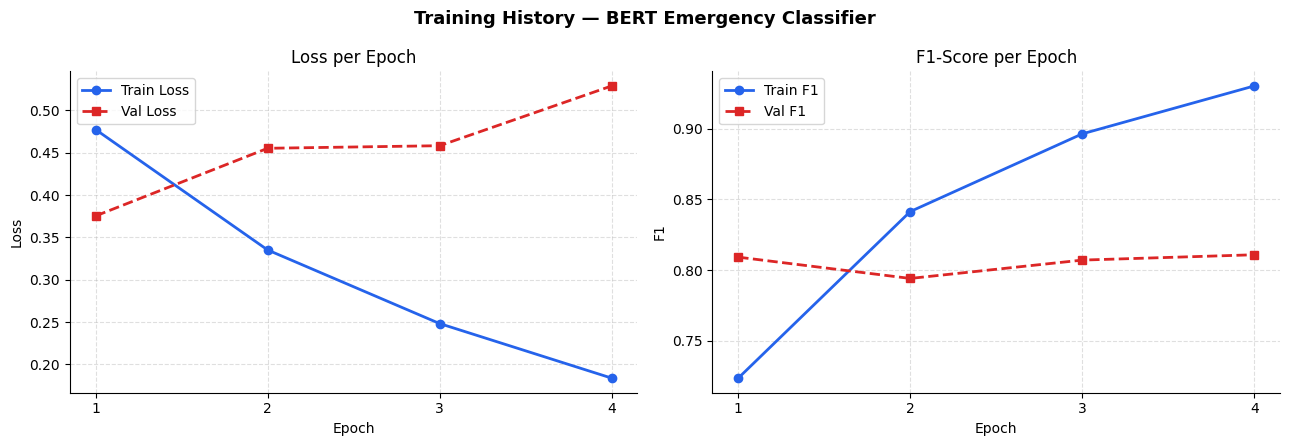

In [19]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Training History — BERT Emergency Classifier',
             fontsize=13, fontweight='bold')

# ── Loss ──────────────────────────────────────────────────────
axes[0].plot(epochs_range, history['train_loss'], 'o-',
             color='#2563EB', label='Train Loss', lw=2)
axes[0].plot(epochs_range, history['val_loss'],   's--',
             color='#DC2626', label='Val Loss',   lw=2)
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.4)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].xaxis.set_major_locator(plt.MaxNLocator(integer=True))

# ── F1 ────────────────────────────────────────────────────────
axes[1].plot(epochs_range, history['train_f1'], 'o-',
             color='#2563EB', label='Train F1', lw=2)
axes[1].plot(epochs_range, history['val_f1'],   's--',
             color='#DC2626', label='Val F1',   lw=2)
axes[1].set_title('F1-Score per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1')
axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.4)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
from sklearn.metrics import classification_report

# Load the best saved checkpoint
model.load_state_dict(torch.load('best_bert_emergency.pt', map_location=DEVICE))
print('✅ Best checkpoint loaded\n')

# Run full evaluation
v = eval_epoch(model, val_loader, DEVICE)

print('════════════════════════════════════')
print('  Final Validation Metrics')
print('════════════════════════════════════')
print(f'  Accuracy  : {v["accuracy"]:.4f}  ({v["accuracy"]*100:.2f}%)')
print(f'  Precision : {v["precision"]:.4f}  ({v["precision"]*100:.2f}%)')
print(f'  Recall    : {v["recall"]:.4f}  ({v["recall"]*100:.2f}%)')
print(f'  F1-Score  : {v["f1"]:.4f}  ({v["f1"]*100:.2f}%)')
print('════════════════════════════════════\n')
print(classification_report(
    v['labels'], v['preds'],
    target_names=['Non-Emergency', 'Emergency']
))

✅ Best checkpoint loaded

════════════════════════════════════
  Final Validation Metrics
════════════════════════════════════
  Accuracy  : 0.8360  (83.60%)
  Precision : 0.8024  (80.24%)
  Recall    : 0.8196  (81.96%)
  F1-Score  : 0.8109  (81.09%)
════════════════════════════════════

               precision    recall  f1-score   support

Non-Emergency       0.86      0.85      0.86       435
    Emergency       0.80      0.82      0.81       327

     accuracy                           0.84       762
    macro avg       0.83      0.83      0.83       762
 weighted avg       0.84      0.84      0.84       762



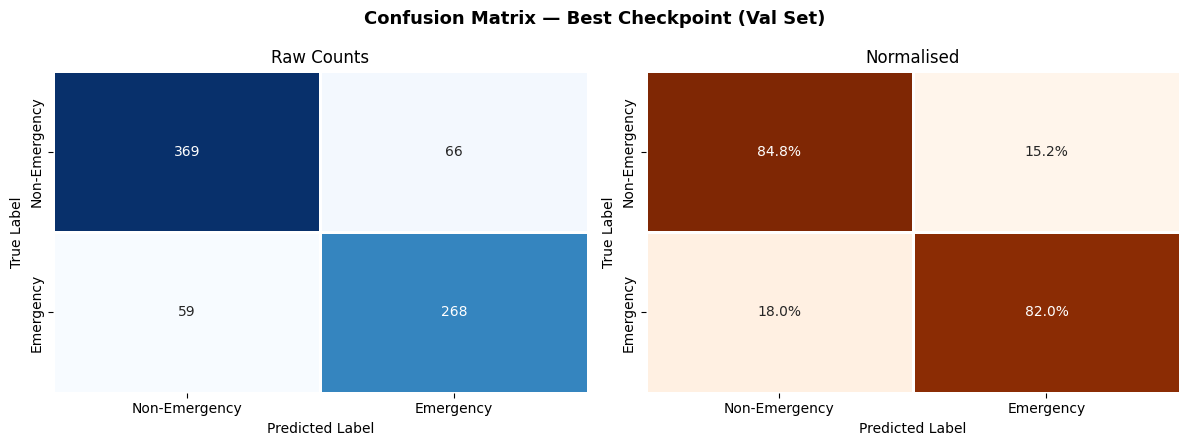

True Negatives  (correctly non-emergency): 369
False Positives (wrongly flagged):         66
False Negatives (missed emergencies):      59
True Positives  (correctly caught):        268


In [21]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

cm      = confusion_matrix(v['labels'], v['preds'])
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle('Confusion Matrix — Best Checkpoint (Val Set)',
             fontsize=13, fontweight='bold')

CLASS_NAMES = ['Non-Emergency', 'Emergency']

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=1, linecolor='white', cbar=False)
axes[0].set_title('Raw Counts')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Normalised
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Oranges', ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=1, linecolor='white', cbar=False)
axes[1].set_title('Normalised')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print what each cell means
tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (correctly non-emergency): {tn}')
print(f'False Positives (wrongly flagged):         {fp}')
print(f'False Negatives (missed emergencies):      {fn}')
print(f'True Positives  (correctly caught):        {tp}')

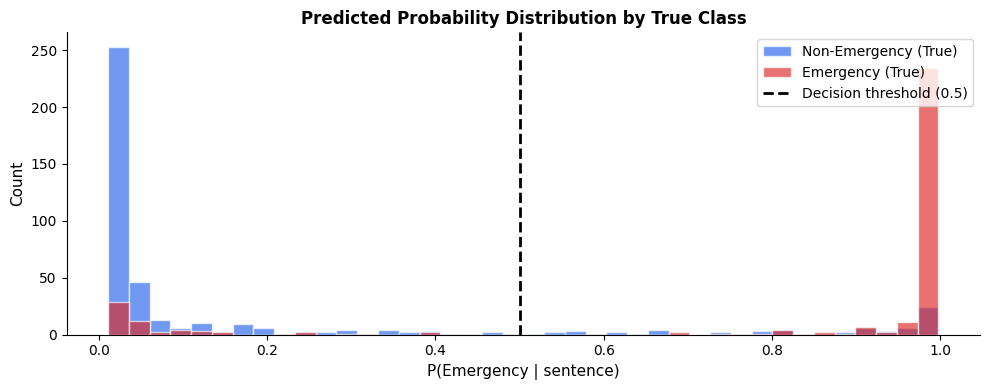

Mean P(emerg) for TRUE non-emergency : 0.180  (want close to 0)
Mean P(emerg) for TRUE emergency     : 0.816  (want close to 1)


In [22]:
import numpy as np

probs  = np.array(v['probs'])
labels = np.array(v['labels'])

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(probs[labels == 0], bins=40, alpha=0.65,
        color='#2563EB', label='Non-Emergency (True)', edgecolor='white')
ax.hist(probs[labels == 1], bins=40, alpha=0.65,
        color='#DC2626', label='Emergency (True)',     edgecolor='white')
ax.axvline(x=0.5, color='black', linestyle='--',
           lw=2, label='Decision threshold (0.5)')

ax.set_xlabel('P(Emergency | sentence)', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Predicted Probability Distribution by True Class',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('probability_dist.png', dpi=150, bbox_inches='tight')
plt.show()

# Separation quality check
print(f'Mean P(emerg) for TRUE non-emergency : {probs[labels==0].mean():.3f}  (want close to 0)')
print(f'Mean P(emerg) for TRUE emergency     : {probs[labels==1].mean():.3f}  (want close to 1)')

In [23]:
def predict(texts, model, tokenizer, device, threshold=0.5, max_len=128):
    """
    Predict emergency probability for a list of raw sentences.

    Args:
        texts     : list[str]  — raw input sentences
        model     : fine-tuned BertForSequenceClassification
        tokenizer : BertTokenizer
        device    : torch.device
        threshold : float — decision boundary (default 0.5)
        max_len   : int   — max token length (default 128)

    Returns:
        list[dict] with keys:
            text        — original input
            probability — P(emergency), 0.0 to 1.0
            label       — 1 (emergency) or 0 (non-emergency)
            verdict     — human-readable string
    """
    model.eval()
    results = []

    for text in texts:
        cleaned = clean_text(text)    # reuse cleaning fn from Cell 9

        enc = tokenizer(
            cleaned,
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        with torch.no_grad():
            logits = model(
                input_ids=enc['input_ids'].to(device),
                attention_mask=enc['attention_mask'].to(device),
                token_type_ids=enc['token_type_ids'].to(device)
            ).logits

        prob = torch.softmax(logits, dim=1)[0][1].item()

        results.append({
            'text'       : text,
            'probability': round(prob, 4),
            'label'      : 1 if prob >= threshold else 0,
            'verdict'    : '🚨 EMERGENCY' if prob >= threshold else '✅ NORMAL'
        })

    return results


print('✅ predict() function defined')

✅ predict() function defined


In [24]:
test_sentences = [
    'I feel like giving up.',
    'Had a great day at the park!',
    'I do not want to wake up tomorrow.',
    'There was a terrible car crash on the highway.',
    'The stock market is absolutely on fire today.',
    'Help! Someone collapsed outside, call an ambulance!',
    'Forest fire near La Ronge Sask. Canada',
    'I am having the time of my life right now.',
]

results = predict(test_sentences, model, tokenizer, DEVICE)

print(f'{"Sentence":<52} {"P(Emerg.)":<12} Verdict')
print('-' * 80)
for r in results:
    print(f'{r["text"][:50]:<52} {r["probability"]:<12.4f} {r["verdict"]}')

Sentence                                             P(Emerg.)    Verdict
--------------------------------------------------------------------------------
I feel like giving up.                               0.1446       ✅ NORMAL
Had a great day at the park!                         0.0254       ✅ NORMAL
I do not want to wake up tomorrow.                   0.2570       ✅ NORMAL
There was a terrible car crash on the highway.       0.9967       🚨 EMERGENCY
The stock market is absolutely on fire today.        0.7125       🚨 EMERGENCY
Help! Someone collapsed outside, call an ambulance   0.9953       🚨 EMERGENCY
Forest fire near La Ronge Sask. Canada               0.9972       🚨 EMERGENCY
I am having the time of my life right now.           0.0419       ✅ NORMAL


In [25]:
import os, shutil

SAVE_DIR = 'bert_emergency_model'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save in HuggingFace format — easiest to reload later
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# Also copy the raw state dict into the same folder
shutil.copy('best_bert_emergency.pt', f'{SAVE_DIR}/best_bert_emergency.pt')

print(f'✅ Model saved to {SAVE_DIR}/')
print(f'   Contents: {os.listdir(SAVE_DIR)}')

✅ Model saved to bert_emergency_model/
   Contents: ['model.safetensors', 'vocab.txt', 'config.json', 'tokenizer_config.json', 'special_tokens_map.json', 'best_bert_emergency.pt']


In [26]:
from google.colab import files

# Zip the model folder
shutil.make_archive('bert_emergency_model', 'zip', SAVE_DIR)
print('✅ Zipped: bert_emergency_model.zip')

# Download both — zip for full model, .pt for just the weights
files.download('bert_emergency_model.zip')    # ~440MB — full HF model
files.download('best_bert_emergency.pt')        # ~420MB — state dict only
print('📥 Downloads started — check your browser downloads')

✅ Zipped: bert_emergency_model.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Downloads started — check your browser downloads


In [27]:
# ── Option A: reload from HuggingFace saved folder (recommended) ──
# from transformers import BertTokenizer, BertForSequenceClassification
# import torch
#
# tokenizer = BertTokenizer.from_pretrained('bert_emergency_model')
# model     = BertForSequenceClassification.from_pretrained('bert_emergency_model')
# model.eval()

# ── Option B: reload from raw state dict ──────────────────────────
# from transformers import BertTokenizer, BertForSequenceClassification
# import torch
#
# tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
# model     = BertForSequenceClassification.from_pretrained(
#                 'bert-base-uncased', num_labels=2)
# model.load_state_dict(torch.load('best_bert_emergency.pt',
#                                   map_location='cpu'))
# model.eval()

print('Reload instructions above — uncomment whichever you need')

Reload instructions above — uncomment whichever you need
